# 📚 Book Recommender System — Exploratory Data Analysis

## 1. Business Problem

## 2. Project Objective

## 3. Import Libraries

## 4. Load Dataset

## 5. Dataset Overview

## 6. Data Quality Assessment

## 7. Missing Values

## 8. Duplicate Records

## 9. Book Statistics

## 10. Author Analysis

## 11. Publication Analysis

## 12. Rating Analysis

## 13. Most Popular Books

## 14. Text/Data Analysis

## 15. Feature Selection

## 16. Key EDA Insights

## 17. Conclusion

## 1. Business Problem

With a large number of books available through online bookstores and digital platforms, users may find it difficult to discover books that match their interests.

A book recommendation system can help users discover relevant books by analyzing book characteristics and identifying similarities between them.

This project aims to develop a machine learning-based recommendation system that recommends books similar to a user's selected book.

## 2. Project Objective

The main objectives of this project are:

- Explore and understand the book dataset.
- Perform data quality assessment and preprocessing.
- Identify useful features for recommendation.
- Analyze book-related information such as authors, ratings, and publication details.
- Build a content-based recommendation system.
- Use TF-IDF to convert textual information into numerical features.
- Calculate cosine similarity between books.
- Recommend the most similar books to a selected title.
- Deploy the recommendation system using Streamlit.

In [1]:
# Import libraries

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# Load the dataset
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "DATA" / "books.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print(f"Dataset shape:{df.shape}")

Dataset Loaded Successfully
Dataset shape:(211, 5)


In [5]:
# Display the first five records

df.head()

,Title,Author,Genre,Height,Publisher
0,Fundamentals of Wavelets,"Goswami, Jaideva",signal_processing,228,Wiley
1,Data Smart,"Foreman, John",data_science,235,Wiley
2,God Created the Integers,"Hawking, Stephen",mathematics,197,Penguin
3,Superfreakonomics,"Dubner, Stephen",economics,179,HarperCollins
4,Orientalism,"Said, Edward",history,197,Penguin


In [6]:
df.columns.tolist()

['Title', 'Author', 'Genre', 'Height', 'Publisher']

In [7]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      211 non-null    object
 1   Author     187 non-null    object
 2   Genre      211 non-null    object
 3   Height     211 non-null    int64 
 4   Publisher  115 non-null    object
dtypes: int64(1), object(4)
memory usage: 8.4+ KB


In [8]:
# check missing values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Title         0
Author       24
Genre         0
Height        0
Publisher    96
dtype: int64


In [9]:
# check duplicate records

duplicate_count = df.duplicated().sum()

print(f"Mumber of duplicate rows: {duplicate_count}")

Mumber of duplicate rows: 0


In [11]:
# Numerical Statics

df.describe()

,Height
count,211.000000
mean,206.056872
std,26.828141
min,160.000000
25%,180.000000
50%,199.000000
75%,229.500000
max,283.000000


In [12]:
# number of unique values in each column

for column in df.columns:
    print(f"{column}: {df[column].unique()}unique values")

Title: ['Fundamentals of Wavelets' 'Data Smart' 'God Created the Integers'
 'Superfreakonomics' 'Orientalism'
 'Nature of Statistical Learning Theory, The'
 'Integration of the Indian States' "Drunkard's Walk, The"
 'Image Processing & Mathematical Morphology'
 'How to Think Like Sherlock Holmes' 'Data Scientists at Work'
 'Slaughterhouse Five' 'Birth of a Theorem'
 'Structure & Interpretation of Computer Programs' 'Age of Wrath, The'
 'Trial, The' "Statistical Decision Theory'" 'Data Mining Handbook'
 'New Machiavelli, The' 'Physics & Philosophy' 'Making Software'
 'Analysis, Vol I' 'Machine Learning for Hackers'
 'Signal and the Noise, The' 'Python for Data Analysis'
 'Introduction to Algorithms' 'Beautiful and the Damned, The'
 'Outsider, The' 'Complete Sherlock Holmes, The - Vol I'
 'Complete Sherlock Holmes, The - Vol II' 'Wealth of Nations, The'
 'Pillars of the Earth, The' 'Mein Kampf' 'Tao of Physics, The'
 "Surely You're Joking Mr Feynman" 'Farewell to Arms, A' 'Veteran, The'


In [13]:
# Books by genre

gnere_counts = df ["Genre"].value_counts()
print(gnere_counts)

Genre
fiction              64
nonfiction           30
history              26
data_science         17
philosophy           17
science              14
comic                13
computer_science     11
economics            10
mathematics           5
signal_processing     3
psychology            1
Name: count, dtype: int64


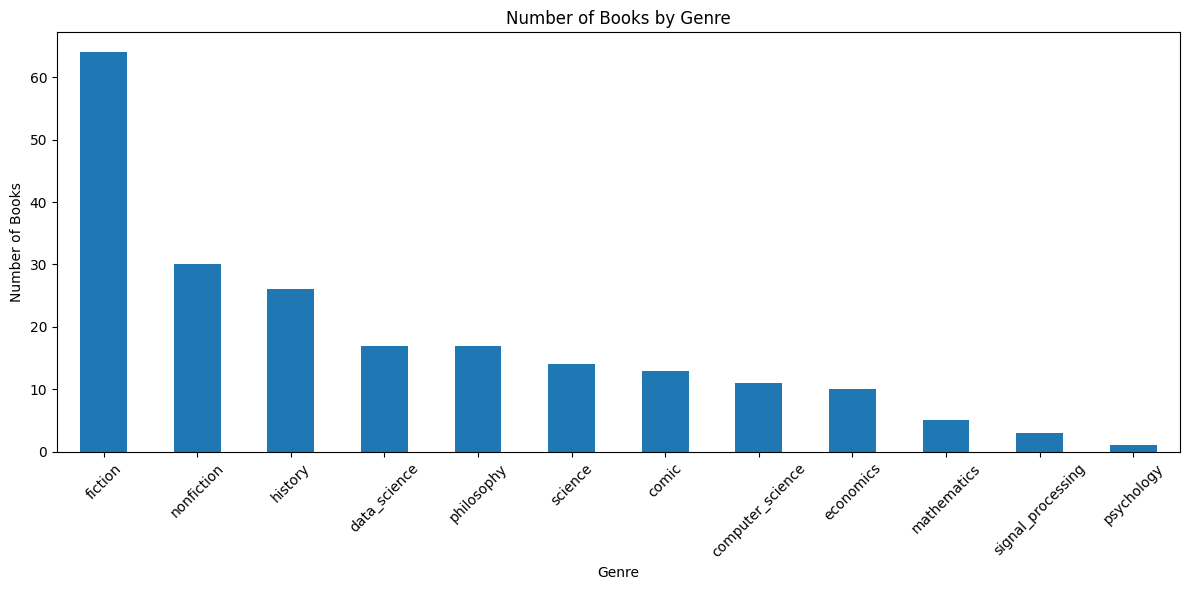

In [16]:
plt.figure(figsize=(12, 6))

gnere_counts.plot(kind="bar")

plt.title("Number of Books by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# top 15 authors

top_authors = df["Author"].value_counts().head(15)
print(top_authors)

Author
Steinbeck, John        8
Deshpande, P L         7
Rutherford, Alex       5
Maugham, William S     4
Sen, Amartya           4
Rand, Ayn              4
Russell, Bertrand      3
Capra, Fritjof         3
Forsyth, Frederick     3
Dalrymple, William     3
Deshpande P L          3
Larsson, Steig         3
Tharoor, Shashi        3
Lapierre, Dominique    3
Dostoevsky, Fyodor     2
Name: count, dtype: int64


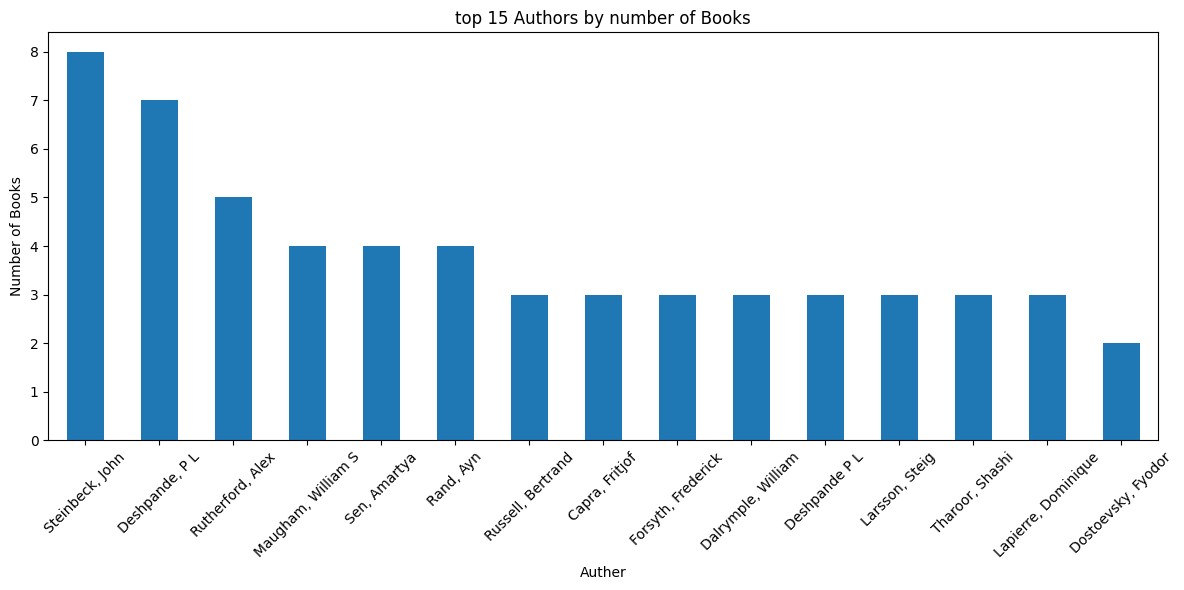

In [19]:
plt.figure(figsize = (12,6))

top_authors.plot(kind = "bar")


plt.title("top 15 Authors by number of Books")
plt.xlabel("Auther")
plt.ylabel("Number of Books")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [ ]:
# Top publishers

top_publishers = df["Publisher"].value_counts().head(15)

print(top_publishers)

In [20]:
# Top publisher

top_publishers = df["Publisher"].value_counts().head(15)
top_publishers

Publisher
Penguin          34
Random House     17
Mauj              7
HarperCollins     6
O'Reilly          4
Vintage           3
MIT Press         3
Springer          3
Rupa              3
Pearson           3
vikas             3
Jaico             3
Wiley             2
Pan               2
Prentice Hall     2
Name: count, dtype: int64

In [21]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

duplicate_percentage = (
    duplicate_count / len(df) * 100
)

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate records: 0
Duplicate percentage: 0.00%


In [22]:
# Check duplicate book titles

duplicate_titles = df["Title"].duplicated().sum()

print("Duplicate titles:", duplicate_titles)

Duplicate titles: 1


In [23]:
# Create a clean copy

df_clean = df.copy()

# Fill missing authors
df_clean["Author"] = df_clean["Author"].fillna("Unknown Author")

# Fill missing publishers
df_clean["Publisher"] = df_clean["Publisher"].fillna("Unknown Publisher")

print("Missing values after handling:")
print(df_clean.isnull().sum())

Missing values after handling:
Title        0
Author       0
Genre        0
Height       0
Publisher    0
dtype: int64


In [24]:
df[df["Title"].duplicated(keep=False)].sort_values("Title")

,Title,Author,Genre,Height,Publisher
65,Angels & Demons,"Brown, Dan",fiction,178,Random House
195,Angels & Demons,"Brown, Dan",fiction,170,NaN


In [25]:
# Remove duplicate book titles
# Keep the record with the most complete information

df_clean = (
    df.sort_values(
        by=["Publisher", "Height"],
        ascending=[False, False],
        na_position="last"
    )
    .drop_duplicates(subset="Title", keep="first")
    .reset_index(drop=True)
)

print("Original records:", len(df))
print("Records after removing duplicate titles:", len(df_clean))

Original records: 211
Records after removing duplicate titles: 210


In [26]:
# Handle missing values

df_clean["Author"] = df_clean["Author"].fillna("Unknown Author")
df_clean["Publisher"] = df_clean["Publisher"].fillna("Unknown Publisher")

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Title        0
Author       0
Genre        0
Height       0
Publisher    0
dtype: int64


In [27]:
# Genre distribution

genre_counts = df_clean["Genre"].value_counts()

print("Number of unique genres:", df_clean["Genre"].nunique())
print("\nGenre distribution:")
print(genre_counts)

Number of unique genres: 12

Genre distribution:
Genre
fiction              63
nonfiction           30
history              26
data_science         17
philosophy           17
science              14
comic                13
computer_science     11
economics            10
mathematics           5
signal_processing     3
psychology            1
Name: count, dtype: int64


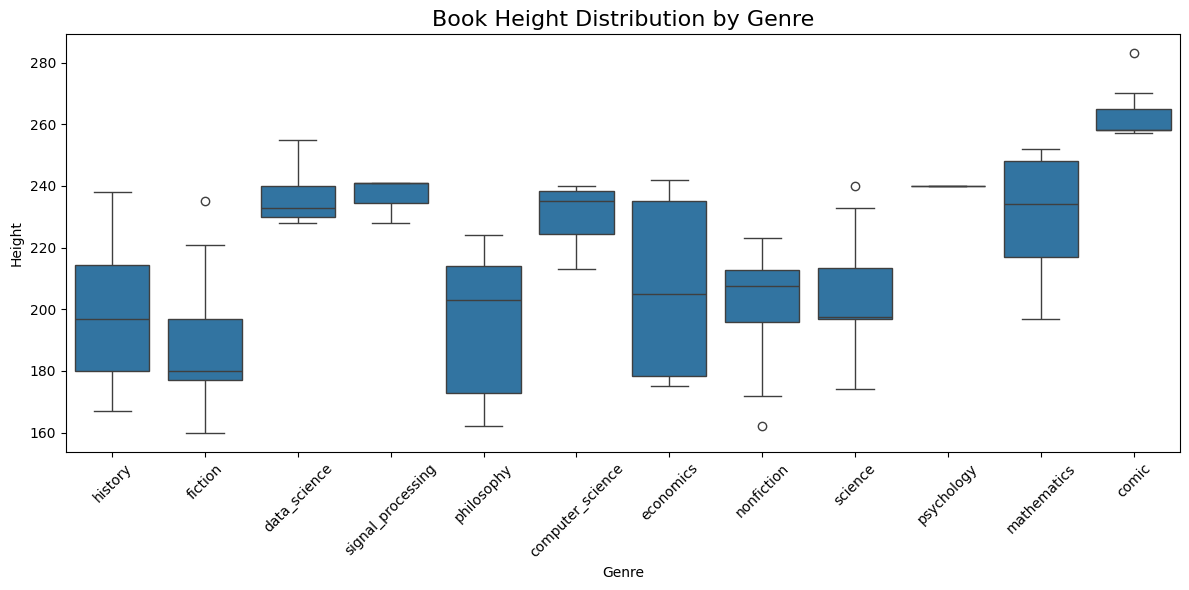

In [28]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x="Genre",
    y="Height"
)

plt.title("Book Height Distribution by Genre", fontsize=16)
plt.xlabel("Genre")
plt.ylabel("Height")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [29]:
# Top 15 authors

author_counts = df_clean["Author"].value_counts().head(15)

print("Top 15 authors:")
print(author_counts)

Top 15 authors:
Author
Unknown Author         24
Steinbeck, John         8
Deshpande, P L          7
Rutherford, Alex        5
Rand, Ayn               4
Maugham, William S      4
Sen, Amartya            4
Lapierre, Dominique     3
Capra, Fritjof          3
Dalrymple, William      3
Deshpande P L           3
Tharoor, Shashi         3
Forsyth, Frederick      3
Larsson, Steig          3
Russell, Bertrand       3
Name: count, dtype: int64


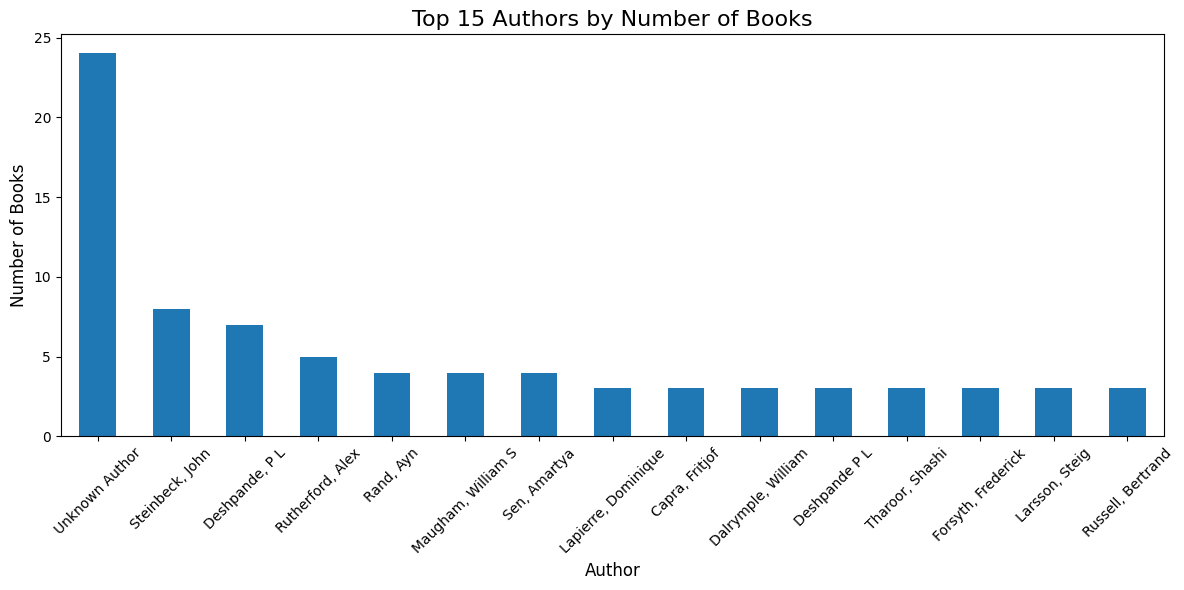

In [30]:
# Visualize top authors

plt.figure(figsize=(12, 6))

author_counts.plot(kind="bar")

plt.title("Top 15 Authors by Number of Books", fontsize=16)
plt.xlabel("Author", fontsize=12)
plt.ylabel("Number of Books", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [31]:
# Top 15 publishers

publisher_counts = df_clean["Publisher"].value_counts().head(15)

print("Top 15 publishers:")
print(publisher_counts)

Top 15 publishers:
Publisher
Unknown Publisher    95
Penguin              34
Random House         17
Mauj                  7
HarperCollins         6
O'Reilly              4
Jaico                 3
vikas                 3
Rupa                  3
Vintage               3
Springer              3
Pearson               3
MIT Press             3
Wiley                 2
Pan                   2
Name: count, dtype: int64


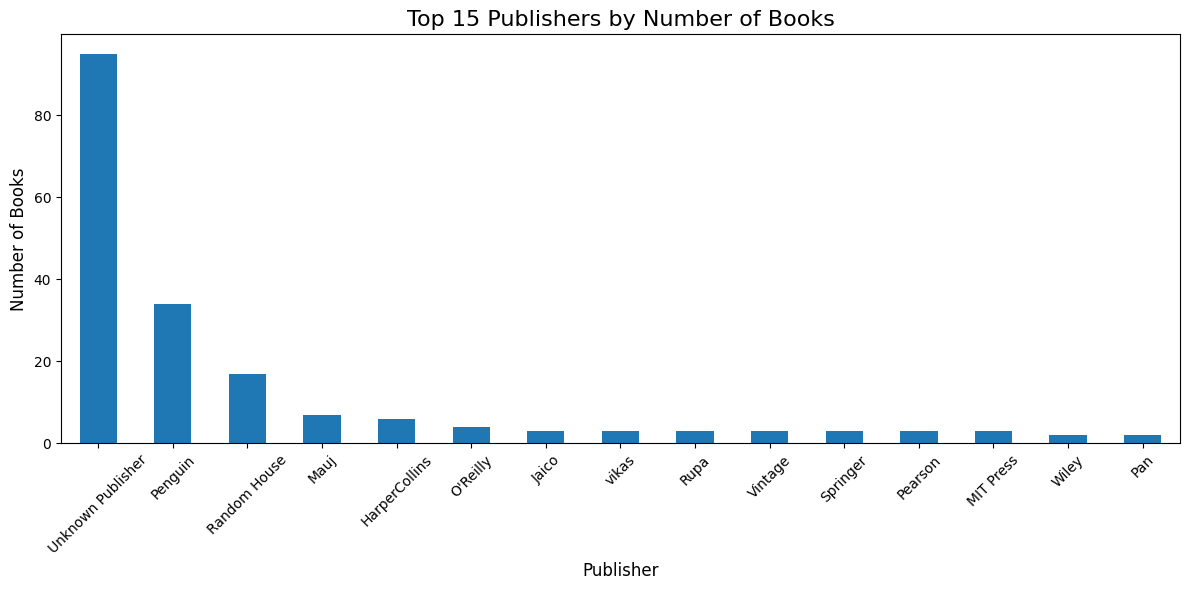

In [32]:
# Publisher visualization

plt.figure(figsize=(12, 6))

publisher_counts.plot(kind="bar")

plt.title("Top 15 Publishers by Number of Books", fontsize=16)
plt.xlabel("Publisher", fontsize=12)
plt.ylabel("Number of Books", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [33]:
# Book height statistics

print("Book Height Statistics:")
print(df_clean["Height"].describe())

Book Height Statistics:
count    210.000000
mean     206.228571
std       26.775786
min      160.000000
25%      180.000000
50%      199.500000
75%      229.750000
max      283.000000
Name: Height, dtype: float64


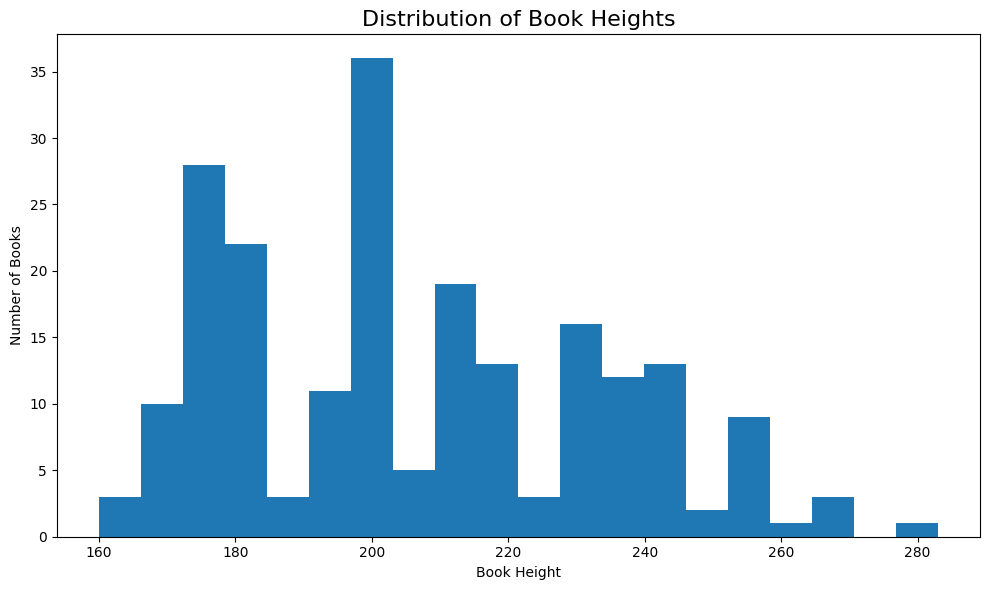

In [34]:
# Distribution of book heights

plt.figure(figsize=(10, 6))

plt.hist(df_clean["Height"], bins=20)

plt.title("Distribution of Book Heights", fontsize=16)
plt.xlabel("Book Height")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

In [35]:
# Smallest and largest books

print("Shortest books:")
display(
    df_clean.nsmallest(10, "Height")[
        ["Title", "Author", "Genre", "Height"]
    ]
)

print("\nTallest books:")
display(
    df_clean.nlargest(10, "Height")[
        ["Title", "Author", "Genre", "Height"]
    ]
)

Shortest books:


,Title,Author,Genre,Height
7,Ashenden of The British Agent,"Maugham, William S",fiction,160
208,Karl Marx Biography,Unknown Author,nonfiction,162
209,Political Philosophers,Unknown Author,philosophy,162
2,Freedom at Midnight,"Lapierre, Dominique",history,167
38,"Story of Philosophy, The","Durant, Will",philosophy,170
206,"Judge, The",Unknown Author,fiction,170
207,"Attorney, The",Unknown Author,fiction,170
6,"Maugham's Collected Short Stories, Vol 3","Maugham, William S",fiction,171
204,Veil: Secret Wars of the CIA,"Woodward, Bob",history,171
205,Philosophy: Who Needs It,"Rand, Ayn",philosophy,171



Tallest books:


,Title,Author,Genre,Height
115,"Killing Joke, The",Unknown Author,comic,283
116,Batman Handbook,Unknown Author,comic,270
117,Flashpoint,Unknown Author,comic,265
118,Batman Earth One,Unknown Author,comic,265
119,Superman Earth One - 1,Unknown Author,comic,259
120,Crisis on Infinite Earths,Unknown Author,comic,258
121,Superman Earth One - 2,Unknown Author,comic,258
122,Justice League: Throne of Atlantis,Unknown Author,comic,258
123,Justice League: The Villain's Journey,Unknown Author,comic,258
124,"Death of Superman, The",Unknown Author,comic,258


In [36]:
# Prepare text features

def normalize_text(text):
    text = str(text).lower()
    text = text.replace(",", " ")
    text = text.replace("-", " ")
    text = " ".join(text.split())
    return text

In [37]:
# Normalize recommendation features

df_clean["author_clean"] = df_clean["Author"].apply(normalize_text)
df_clean["genre_clean"] = df_clean["Genre"].apply(normalize_text)
df_clean["publisher_clean"] = df_clean["Publisher"].apply(normalize_text)

In [38]:
# Standardize known author-name variations

df_clean["author_clean"] = df_clean["author_clean"].replace(
    {
        "deshpande p l": "deshpande pl",
        "deshpande  p l": "deshpande pl",
    }
)

In [39]:
# Combine important book attributes

df_clean["combined_features"] = (
    df_clean["author_clean"] + " " +
    df_clean["genre_clean"] + " " +
    df_clean["publisher_clean"]
)

In [40]:
# Display recommendation features

df_clean[
    [
        "Title",
        "Author",
        "Genre",
        "Publisher",
        "combined_features"
    ]
].head(10)

,Title,Author,Genre,Publisher,combined_features
0,O Jerusalem!,"Lapierre, Dominique",history,vikas,lapierre dominique history vikas
1,"City of Joy, The","Lapierre, Dominique",fiction,vikas,lapierre dominique fiction vikas
2,Freedom at Midnight,"Lapierre, Dominique",history,vikas,lapierre dominique history vikas
3,Data Smart,"Foreman, John",data_science,Wiley,foreman john data_science wiley
4,Fundamentals of Wavelets,"Goswami, Jaideva",signal_processing,Wiley,goswami jaideva signal_processing wiley
5,Zen & The Art of Motorcycle Maintenance,"Pirsig, Robert",philosophy,Vintage,pirsig robert philosophy vintage
6,"Maugham's Collected Short Stories, Vol 3","Maugham, William S",fiction,Vintage,maugham william s fiction vintage
7,Ashenden of The British Agent,"Maugham, William S",fiction,Vintage,maugham william s fiction vintage
8,"Veteran, The","Forsyth, Frederick",fiction,Transworld,forsyth frederick fiction transworld
9,Principles of Communication Systems,"Taub, Schilling",computer_science,TMH,taub schilling computer_science tmh


In [41]:
df_clean[
    ["Title", "combined_features"]
].head(10)

,Title,combined_features
0,O Jerusalem!,lapierre dominique history vikas
1,"City of Joy, The",lapierre dominique fiction vikas
2,Freedom at Midnight,lapierre dominique history vikas
3,Data Smart,foreman john data_science wiley
4,Fundamentals of Wavelets,goswami jaideva signal_processing wiley
5,Zen & The Art of Motorcycle Maintenance,pirsig robert philosophy vintage
6,"Maugham's Collected Short Stories, Vol 3",maugham william s fiction vintage
7,Ashenden of The British Agent,maugham william s fiction vintage
8,"Veteran, The",forsyth frederick fiction transworld
9,Principles of Communication Systems,taub schilling computer_science tmh


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1
)

# Transform combined features into TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(
    df_clean["combined_features"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (210, 604)


In [43]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity between all books
cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine similarity shape:", cosine_sim.shape)

Cosine similarity shape: (210, 210)


In [44]:
# Create title-to-index mapping

indices = pd.Series(
    df_clean.index,
    index=df_clean["Title"]
).drop_duplicates()

print(indices.head())

Title
O Jerusalem!                0
City of Joy, The            1
Freedom at Midnight         2
Data Smart                  3
Fundamentals of Wavelets    4
dtype: int64


In [45]:
def recommend_books(title, num_recommendations=5):

    # Check whether book exists
    if title not in indices:
        return f"Book '{title}' not found in the dataset."

    # Get index of selected book
    idx = indices[title]

    # Get similarity scores
    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    # Sort by similarity score
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected book itself
    similarity_scores = similarity_scores[1:num_recommendations + 1]

    # Get book indices
    book_indices = [
        i[0] for i in similarity_scores
    ]

    # Return recommended books
    recommendations = df_clean.iloc[
        book_indices
    ][
        [
            "Title",
            "Author",
            "Genre",
            "Publisher"
        ]
    ].copy()

    recommendations["similarity_score"] = [
        round(i[1], 4)
        for i in similarity_scores
    ]

    return recommendations

In [46]:
recommend_books("Data Smart", 5)

,Title,Author,Genre,Publisher,similarity_score
92,Statistical Decision Theory',"Pratt, John",data_science,MIT Press,0.2726
4,Fundamentals of Wavelets,"Goswami, Jaideva",signal_processing,Wiley,0.1419
177,"Grapes of Wrath, The","Steinbeck, John",fiction,Unknown Publisher,0.1165
61,Journal of a Novel,"Steinbeck, John",fiction,Penguin,0.1147
63,"Moon is Down, The","Steinbeck, John",fiction,Penguin,0.1147


In [47]:
recommend_books("Angels & Demons", 5)

,Title,Author,Genre,Publisher,similarity_score
35,"Brethren, The","Grisham, John",fiction,Random House,0.3310
20,"Trial, The","Kafka, Frank",fiction,Random House,0.3068
34,Jurassic Park,"Crichton, Michael",fiction,Random House,0.3068
19,Slaughterhouse Five,"Vonnegut, Kurt",fiction,Random House,0.3031
24,"Amulet of Samarkand, The","Stroud, Jonathan",fiction,Random House,0.3031


In [49]:
# Create weighted features

df_clean["weighted_features"] = (
    df_clean["Genre"].fillna("").str.lower() + " " +
    df_clean["Genre"].fillna("").str.lower() + " " +
    df_clean["Genre"].fillna("").str.lower() + " " +
    df_clean["Author"].fillna("").str.lower() + " " +
    df_clean["Author"].fillna("").str.lower() + " " +
    df_clean["Publisher"].fillna("").str.lower()
)

df_clean[[
    "Title",
    "Genre",
    "Author",
    "Publisher",
    "weighted_features"
]].head(10)

,Title,Genre,Author,Publisher,weighted_features
0,O Jerusalem!,history,"Lapierre, Dominique",vikas,"history history history lapierre, dominique la..."
1,"City of Joy, The",fiction,"Lapierre, Dominique",vikas,"fiction fiction fiction lapierre, dominique la..."
2,Freedom at Midnight,history,"Lapierre, Dominique",vikas,"history history history lapierre, dominique la..."
3,Data Smart,data_science,"Foreman, John",Wiley,data_science data_science data_science foreman...
4,Fundamentals of Wavelets,signal_processing,"Goswami, Jaideva",Wiley,signal_processing signal_processing signal_pro...
5,Zen & The Art of Motorcycle Maintenance,philosophy,"Pirsig, Robert",Vintage,"philosophy philosophy philosophy pirsig, rober..."
6,"Maugham's Collected Short Stories, Vol 3",fiction,"Maugham, William S",Vintage,"fiction fiction fiction maugham, william s mau..."
7,Ashenden of The British Agent,fiction,"Maugham, William S",Vintage,"fiction fiction fiction maugham, william s mau..."
8,"Veteran, The",fiction,"Forsyth, Frederick",Transworld,"fiction fiction fiction forsyth, frederick for..."
9,Principles of Communication Systems,computer_science,"Taub, Schilling",TMH,computer_science computer_science computer_sci...


In [51]:

#Rebuild TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1
)

tfidf_matrix = tfidf.fit_transform(
    df_clean["weighted_features"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (210, 819)


In [53]:

#Recalculate Cosine Similarity
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

print("Cosine similarity shape:", cosine_sim.shape)

Cosine similarity shape: (210, 210)


In [54]:
recommend_books("Data Smart", 5)

,Title,Author,Genre,Publisher,similarity_score
92,Statistical Decision Theory',"Pratt, John",data_science,MIT Press,0.3487
145,Statistical Learning Theory,"Vapnik, Vladimir",data_science,Unknown Publisher,0.2642
11,"Nature of Statistical Learning Theory, The","Vapnik, Vladimir",data_science,Springer,0.2609
131,Neural Networks,"Haykin, Simon",data_science,Unknown Publisher,0.2606
74,"Computer Vision, A Modern Approach","Forsyth, David",data_science,Pearson,0.2595


In [55]:
recommend_books("Data Smart", 5)

,Title,Author,Genre,Publisher,similarity_score
92,Statistical Decision Theory',"Pratt, John",data_science,MIT Press,0.3487
145,Statistical Learning Theory,"Vapnik, Vladimir",data_science,Unknown Publisher,0.2642
11,"Nature of Statistical Learning Theory, The","Vapnik, Vladimir",data_science,Springer,0.2609
131,Neural Networks,"Haykin, Simon",data_science,Unknown Publisher,0.2606
74,"Computer Vision, A Modern Approach","Forsyth, David",data_science,Pearson,0.2595


In [56]:
def recommend_books(book_title, n=5):

    # Check whether book exists
    if book_title not in df_clean["Title"].values:
        return f"Book '{book_title}' not found."

    # Get index
    book_index = df_clean[
        df_clean["Title"] == book_title
    ].index[0]

    # Get similarity scores
    similarity_scores = list(
        enumerate(cosine_sim[book_index])
    )

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected book itself
    similarity_scores = [
        item for item in similarity_scores
        if item[0] != book_index
    ]

    # Get top N
    top_books = similarity_scores[:n]

    # Create results
    recommendations = []

    for index, score in top_books:

        recommendations.append({
            "Title": df_clean.loc[index, "Title"],
            "Author": df_clean.loc[index, "Author"],
            "Genre": df_clean.loc[index, "Genre"],
            "Publisher": df_clean.loc[index, "Publisher"],
            "similarity_score": round(score, 4)
        })

    return pd.DataFrame(recommendations)

In [57]:
recommend_books("Data Smart", 5)

,Title,Author,Genre,Publisher,similarity_score
0,Statistical Decision Theory',"Pratt, John",data_science,MIT Press,0.3487
1,Statistical Learning Theory,"Vapnik, Vladimir",data_science,Unknown Publisher,0.2642
2,"Nature of Statistical Learning Theory, The","Vapnik, Vladimir",data_science,Springer,0.2609
3,Neural Networks,"Haykin, Simon",data_science,Unknown Publisher,0.2606
4,"Computer Vision, A Modern Approach","Forsyth, David",data_science,Pearson,0.2595


In [58]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    tfidf,
    MODEL_DIR / "tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


In [59]:
joblib.dump(
    cosine_sim,
    MODEL_DIR / "cosine_similarity.pkl"
)

print("Cosine similarity saved successfully.")

Cosine similarity saved successfully.


In [60]:
df_clean[
    [
        "Title",
        "Author",
        "Genre",
        "Publisher"
    ]
].to_pickle(
    MODEL_DIR / "books_data.pkl"
)

print("Book data saved successfully.")

Book data saved successfully.
